<a href="https://colab.research.google.com/github/sharare-bazdar/Sharare-/blob/main/RNN_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import  keras
from tensorflow.keras import models , layers

In [ ]:
np.random.seed(42)


In [ ]:
x=np.linspace(0,100,num=1000)
y=np.sin(x)+np.random.normal(scale=0.1,size = x.shape)

In [ ]:
def create_dataset(data,time_step=1):
  x,y=[],[]
  for i in range(len(data)-time_step):
    x.append(data[i:(i+time_step)])
    y.append(data[i+time_step])
  return np.array(x) , np.array(y)

In [ ]:
time_step = 10
x,y=create_dataset(y,time_step)

In [ ]:
x=x.reshape(x.shape[0] , x.shape[1],1)

In [ ]:
train_size=int(len(x)*0.8)
x_train,x_test=x[:train_size],x[train_size:]
y_train,y_test=y[:train_size],y[train_size:]


In [ ]:
model=keras.Sequential()
model.add(layers.SimpleRNN(50,activation='relu',input_shape=(time_step,1)))
model.add(layers.Dense(1))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam' , loss = 'mean_squared_error')

In [ ]:
history = model.fit(x_train,y_train,epochs=50,batch_size=32,verbose=1)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2920
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0484
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0192
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0173
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0158
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0163
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0143
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0142
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0134
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0143
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0156
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0146
Epoch 13/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0139
Epoch 14/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0145
Epoch 15/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0150
Epoch 16/50
25/25 

In [ ]:
y_pred = model.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [ ]:
print(f'len y_test' , len(y_test))
print(f'len y_pred' , len(y_pred))

len y_test 198
len y_pred 198


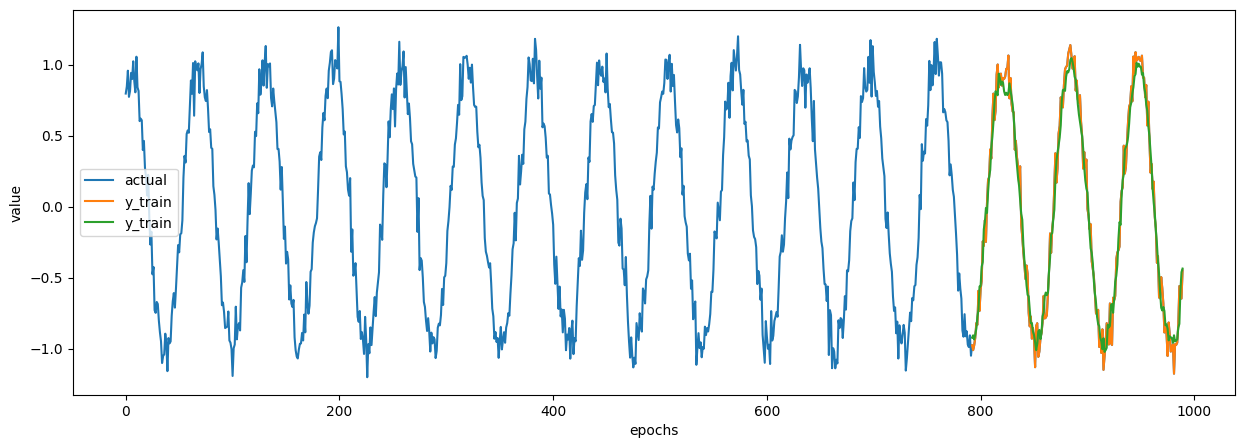

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(np.arange(len(y)) , y,label='actual')
plt.plot(np.arange(len(x_train) ,len(x_train)+len(y_test)) , y_test,label='y_train')
plt.plot(np.arange(len(x_train) ,len(x_train)+len(y_pred)) , y_pred,label='y_train')
plt.xlabel('epochs')
plt.ylabel('value')
plt.legend()
plt.show()